In [1]:
with open('/content/description.txt', 'r') as f:
    description_content = f.read()
print(description_content)

Train data:
ID ::: TITLE ::: GENRE ::: DESCRIPTION
ID ::: TITLE ::: GENRE ::: DESCRIPTION
ID ::: TITLE ::: GENRE ::: DESCRIPTION
ID ::: TITLE ::: GENRE ::: DESCRIPTION

Test data:
ID ::: TITLE ::: DESCRIPTION
ID ::: TITLE ::: DESCRIPTION
ID ::: TITLE ::: DESCRIPTION
ID ::: TITLE ::: DESCRIPTION

Source:
ftp://ftp.fu-berlin.de/pub/misc/movies/database/


In [2]:
import pandas as pd

# Load training data
with open('/content/train_data.txt', 'r') as f:
    train_data = [line.strip() for line in f]

# Load test data
with open('/content/test_data.txt', 'r') as f:
    test_data = [line.strip() for line in f]

print(f"Number of training samples: {len(train_data)}")
print(f"Number of test samples: {len(test_data)}")

print('\nFirst 5 training samples:')
for i in range(min(5, len(train_data))):
    print(train_data[i])

print('\nFirst 5 test samples:')
for i in range(min(5, len(test_data))):
    print(test_data[i])

Number of training samples: 54214
Number of test samples: 54200

First 5 training samples:
1 ::: Oscar et la dame rose (2009) ::: drama ::: Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.
2 ::: Cupid (1997) ::: thriller ::: A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close to him.
3 ::: Young, Wild and Wonderful (1980) ::: adult ::: As the bus empties the students for their

## 3. Data Parsing and Structuring
Let's parse the raw data into Pandas DataFrames, separating the `ID`, `TITLE`, `GENRE` (for training), and `DESCRIPTION`.

In [19]:
import numpy as np

def parse_data(data_list, is_train=True):2
    ids = []
    titles = []
    genres = []
    descriptions = []

    for line in data_list:
        parts = line.split(' ::: ')
        ids.append(parts[0])
        titles.append(parts[1])
        if is_train:
            genres.append(parts[2].split(', ')) # Split genres into a list
            descriptions.append(parts[3])
        else:
            # For test data, genre is not present, description is at parts[2]
            descriptions.append(parts[2])

    if is_train:
        df = pd.DataFrame({
            'ID': ids,
            'TITLE': titles,
            'GENRE': genres,
            'DESCRIPTION': descriptions
        })
    else:
        df = pd.DataFrame({
            'ID': ids,
            'TITLE': titles,
            'DESCRIPTION': descriptions
        })
    return df

# Parse training data
train_df = parse_data(train_data, is_train=True)

# Parse test data
test_df = parse_data(test_data, is_train=False)

print('Train DataFrame head:')
print(train_df.head())
print('\nTrain DataFrame info:')
train_df.info()

print('\nTest DataFrame head:')
print(test_df.head())
print('\nTest DataFrame info:')
test_df.info()

Train DataFrame head:
  ID                             TITLE       GENRE  \
0  1      Oscar et la dame rose (2009)     [drama]   
1  2                      Cupid (1997)  [thriller]   
2  3  Young, Wild and Wonderful (1980)     [adult]   
3  4             The Secret Sin (1915)     [drama]   
4  5            The Unrecovered (2007)     [drama]   

                                         DESCRIPTION  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  
3  To help their unemployed father make ends meet...  
4  The film's title refers not only to the un-rec...  

Train DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54214 non-null  object
 1   TITLE        54214 non-null  object
 2   GENRE        54214 non-

## 4. Exploratory Data Analysis (EDA)
Let's analyze the distribution of genres in our training dataset.

Top 20 Genres:
          Genre  Count
0         drama  13613
3   documentary  13096
4        comedy   7447
12        short   5073
7        horror   2204
1      thriller   1591
10       action   1315
17      western   1032
6    reality-tv    884
18       family    784
15    adventure    775
14        music    731
23      romance    672
13       sci-fi    647
2         adult    590
5         crime    505
9     animation    498
8         sport    432
16    talk-show    391
11      fantasy    323


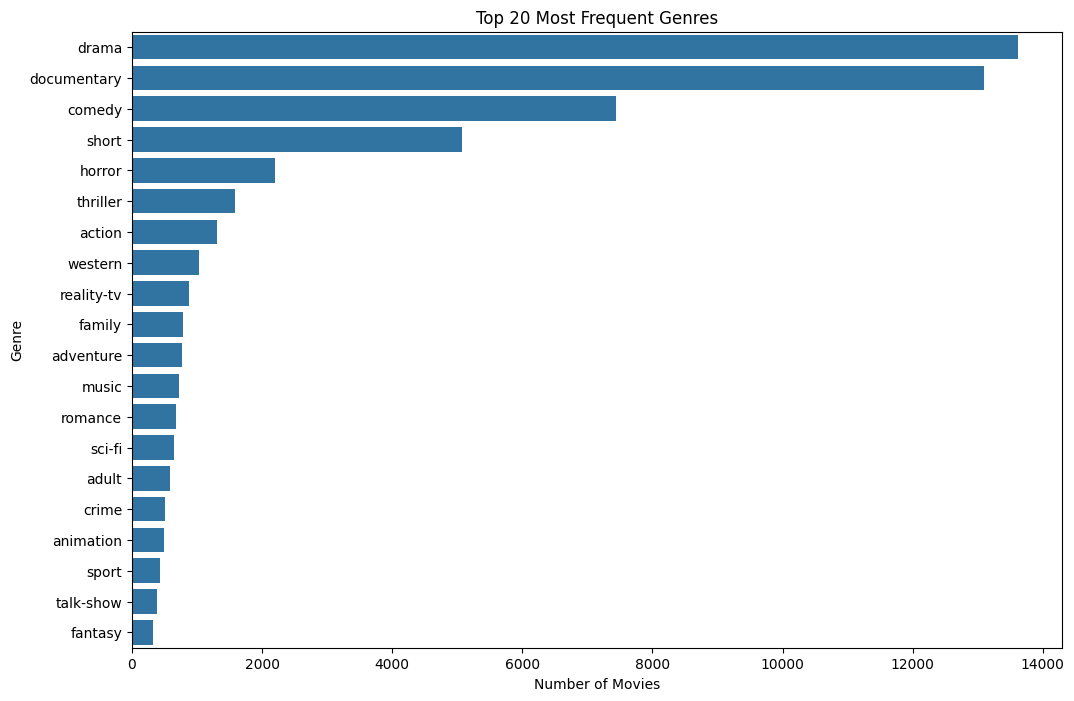


Number of unique genres: 27

Average description length: 599.45


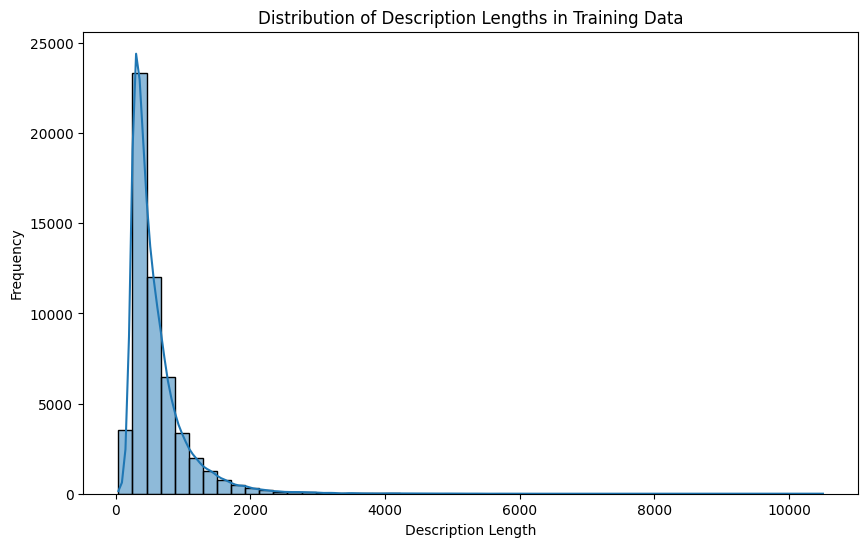

In [4]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the list of genres to count occurrences
all_genres = [genre for sublist in train_df['GENRE'] for genre in sublist]
genre_counts = Counter(all_genres)

# Convert to DataFrame for easier plotting
genre_counts_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count'])
genre_counts_df = genre_counts_df.sort_values(by='Count', ascending=False)

print('Top 20 Genres:')
print(genre_counts_df.head(20))

# Plotting the top 20 genres
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Genre', data=genre_counts_df.head(20))
plt.title('Top 20 Most Frequent Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

# Also check the number of unique genres
num_unique_genres = len(genre_counts)
print(f"\nNumber of unique genres: {num_unique_genres}")

# Check the distribution of descriptions length
train_df['description_length'] = train_df['DESCRIPTION'].apply(len)
print(f"\nAverage description length: {train_df['description_length'].mean():.2f}")
plt.figure(figsize=(10, 6))
sns.histplot(train_df['description_length'], bins=50, kde=True)
plt.title('Distribution of Description Lengths in Training Data')
plt.xlabel('Description Length')
plt.ylabel('Frequency')
plt.show()

## 5. Text Preprocessing and Feature Extraction
We'll combine the `TITLE` and `DESCRIPTION` fields, preprocess the text, and then convert it into numerical features using TF-IDF.

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Download NLTK stop words (if not already downloaded)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation and special characters
    text = ' '.join([word for word in text.split() if word not in stop_words]) # Remove stop words
    return text

# Combine title and description and preprocess
train_df['full_text'] = train_df['TITLE'] + ' ' + train_df['DESCRIPTION']
test_df['full_text'] = test_df['TITLE'] + ' ' + test_df['DESCRIPTION']

train_df['preprocessed_text'] = train_df['full_text'].apply(preprocess_text)
test_df['preprocessed_text'] = test_df['full_text'].apply(preprocess_text)

print('First 5 preprocessed training samples:')
for i in range(min(5, len(train_df))):
    print(train_df['preprocessed_text'].iloc[i])

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency

# Fit on training data and transform both train and test data
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['preprocessed_text'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['preprocessed_text'])

print(f"\nShape of TF-IDF transformed training data: {X_train_tfidf.shape}")
print(f"Shape of TF-IDF transformed test data: {X_test_tfidf.shape}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


First 5 preprocessed training samples:
oscar et la dame rose 2009 listening conversation doctor parents 10yearold oscar learns nobody courage tell weeks live furious refuses speak anyone except straighttalking rose lady pink meets hospital stairs christmas approaches rose uses fantastical experiences professional wrestler imagination wit charm allow oscar live life love full company friends pop corn einstein bacon childhood sweetheart peggy blue
cupid 1997 brother sister past incestuous relationship current murderous relationship murders women reject murders women get close
young wild wonderful 1980 bus empties students field trip museum natural history little tour guide suspect students another tour first lecture films coeds drift dreams erotic fantasies one imagine films release emotion fantasies erotic uncommon ways one slips curators office little acquisition another finds anthropologist see bones identified even head teacher isnt immune soon tour bus departs everyone admits quite 

## 5.1. Feature Extraction using Word Embeddings (spaCy)

In [17]:
# Install spaCy
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [18]:
import spacy

# Load the English language model
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'...")
    !python -m spacy download en_core_web_sm
    nlp = spacy.load('en_core_web_sm')

# Function to get document embeddings
def get_word_embedding(text):
    doc = nlp(text)
    # Return the average of the word vectors; return zeros if no vectors are found
    if doc.has_vector:
        return doc.vector
    else:
        # Return a zero vector of the appropriate dimension if no words have vectors
        # Assuming a common embedding dimension like 96 for 'en_core_web_sm'
        return np.zeros(nlp('test').vector.shape[0])

# Apply the function to create embeddings for full_text
# Note: This can be computationally intensive for large datasets
print("Generating word embeddings for training data...")
X_train_word_embeddings = np.array([get_word_embedding(text) for text in train_df['preprocessed_text']])

print("Generating word embeddings for test data...")
X_test_word_embeddings = np.array([get_word_embedding(text) for text in test_df['preprocessed_text']])

print(f"\nShape of word embedding transformed training data: {X_train_word_embeddings.shape}")
print(f"Shape of word embedding transformed test data: {X_test_word_embeddings.shape}")

Generating word embeddings for training data...
Generating word embeddings for test data...

Shape of word embedding transformed training data: (54214, 96)
Shape of word embedding transformed test data: (54200, 96)


## 6.4. Train a Classifier with Word Embeddings

In [20]:
# Split training data into training and validation sets for word embeddings
X_train_emb, X_val_emb, y_train_emb, y_val_emb = train_test_split(
    X_train_word_embeddings, y_train_mlb, test_size=0.2, random_state=42
)

print(f"Shape of X_train_emb: {X_train_emb.shape}")
print(f"Shape of X_val_emb: {X_val_emb.shape}")

# Train a multi-label classifier with word embeddings (OneVsRestClassifier with Logistic Regression)
emb_classifier = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
emb_classifier.fit(X_train_emb, y_train_emb)

# Make predictions on the validation set
y_pred_emb = emb_classifier.predict(X_val_emb)
y_pred_proba_emb = emb_classifier.predict_proba(X_val_emb)

# Evaluate the model
accuracy_emb = accuracy_score(y_val_emb, y_pred_emb)
f1_macro_emb = f1_score(y_val_emb, y_pred_emb, average='macro')
f1_micro_emb = f1_score(y_val_emb, y_pred_emb, average='micro')

print(f"\nWord Embeddings Model Evaluation on Validation Set (Logistic Regression):")
print(f"Accuracy: {accuracy_emb:.4f}")
print(f"F1-score (Macro): {f1_macro_emb:.4f}")
print(f"F1-score (Micro): {f1_micro_emb:.4f}")

# Calculate ROC AUC score for each label and average
roc_auc_scores_emb = []
for i in range(y_val_emb.shape[1]):
    if np.sum(y_val_emb[:, i]) > 0 and np.std(y_val_emb[:, i]) > 0:
        try:
            roc_auc_scores_emb.append(roc_auc_score(y_val_emb[:, i], y_pred_proba_emb[:, i]))
        except ValueError:
            continue

if roc_auc_scores_emb:
    roc_auc_macro_emb = np.mean(roc_auc_scores_emb)
    print(f"ROC AUC (Macro averaged over valid classes) [Word Embeddings]: {roc_auc_macro_emb:.4f}")
else:
    print("ROC AUC (Word Embeddings) cannot be calculated (no valid classes with both positive and negative samples).")

Shape of X_train_emb: (43371, 96)
Shape of X_val_emb: (10843, 96)

Word Embeddings Model Evaluation on Validation Set (Logistic Regression):
Accuracy: 0.1038
F1-score (Macro): 0.0246
F1-score (Micro): 0.1762
ROC AUC (Macro averaged over valid classes) [Word Embeddings]: 0.7282


## 6.5. Compare F1-scores of different models

## 6. Target Variable Encoding and Model Training
We'll encode the multi-label genres and train a `OneVsRestClassifier`.

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Encode multi-label genres
mlb = MultiLabelBinarizer()
y_train_mlb = mlb.fit_transform(train_df['GENRE'])

print(f"Shape of encoded training labels: {y_train_mlb.shape}")
print(f"All genre labels: {list(mlb.classes_)}")

# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_tfidf, y_train_mlb, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

# Train a multi-label classifier (OneVsRestClassifier with Logistic Regression)
classifier = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))
classifier.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = classifier.predict(X_val)
y_pred_proba = classifier.predict_proba(X_val)

# Evaluate the model
accuracy = accuracy_score(y_val, y_pred)
f1_macro = f1_score(y_val, y_pred, average='macro')
f1_micro = f1_score(y_val, y_pred, average='micro')

print(f"\nModel Evaluation on Validation Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score (Macro): {f1_macro:.4f}")
print(f"F1-score (Micro): {f1_micro:.4f}")

# Calculate ROC AUC score for each label and average
# Handle the case where a class might have only one sample in y_val or y_pred
roc_auc_scores = []
for i in range(y_val.shape[1]):
    if np.sum(y_val[:, i]) > 0 and np.std(y_val[:, i]) > 0:
        try:
            roc_auc_scores.append(roc_auc_score(y_val[:, i], y_pred_proba[:, i]))
        except ValueError:
            continue # Skip if an error occurs (e.g., only one class present)

if roc_auc_scores:
    roc_auc_macro = np.mean(roc_auc_scores)
    print(f"ROC AUC (Macro averaged over valid classes): {roc_auc_macro:.4f}")
else:
    print("ROC AUC cannot be calculated (no valid classes with both positive and negative samples).")

Shape of encoded training labels: (54214, 27)
All genre labels: ['action', 'adult', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'short', 'sport', 'talk-show', 'thriller', 'war', 'western']

Shape of X_train: (43371, 5000)
Shape of X_val: (10843, 5000)
Shape of y_train: (43371, 27)
Shape of y_val: (10843, 27)

Model Evaluation on Validation Set:
Accuracy: 0.3511
F1-score (Macro): 0.1602
F1-score (Micro): 0.4865
ROC AUC (Macro averaged over valid classes): 0.9130


## 6.1. Train a Naive Bayes Classifier

In [14]:
from sklearn.naive_bayes import MultinomialNB

# Train a OneVsRestClassifier with Multinomial Naive Bayes
nb_classifier = OneVsRestClassifier(MultinomialNB())
nb_classifier.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_nb = nb_classifier.predict(X_val)
y_pred_proba_nb = nb_classifier.predict_proba(X_val)

# Evaluate the Naive Bayes model
accuracy_nb = accuracy_score(y_val, y_pred_nb)
f1_macro_nb = f1_score(y_val, y_pred_nb, average='macro')
f1_micro_nb = f1_score(y_val, y_pred_nb, average='micro')

print(f"\nNaive Bayes Model Evaluation on Validation Set:")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"F1-score (Macro): {f1_macro_nb:.4f}")
print(f"F1-score (Micro): {f1_micro_nb:.4f}")

# Calculate ROC AUC score for each label and average for Naive Bayes
roc_auc_scores_nb = []
for i in range(y_val.shape[1]):
    if np.sum(y_val[:, i]) > 0 and np.std(y_val[:, i]) > 0:
        try:
            roc_auc_scores_nb.append(roc_auc_score(y_val[:, i], y_pred_proba_nb[:, i]))
        except ValueError:
            continue # Skip if an error occurs

if roc_auc_scores_nb:
    roc_auc_macro_nb = np.mean(roc_auc_scores_nb)
    print(f"ROC AUC (Macro averaged over valid classes) [Naive Bayes]: {roc_auc_macro_nb:.4f}")
else:
    print("ROC AUC (Naive Bayes) cannot be calculated (no valid classes with both positive and negative samples).")


Naive Bayes Model Evaluation on Validation Set:
Accuracy: 0.2566
F1-score (Macro): 0.0815
F1-score (Micro): 0.3821
ROC AUC (Macro averaged over valid classes) [Naive Bayes]: 0.8422


## 6.2. Train a Support Vector Machine (SVM) Classifier

In [15]:
from sklearn.svm import LinearSVC

# Train a OneVsRestClassifier with Linear Support Vector Classifier
svm_classifier = OneVsRestClassifier(LinearSVC(random_state=42, dual=False)) # dual=False recommended for n_samples > n_features
svm_classifier.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_svm = svm_classifier.predict(X_val)

# For ROC AUC, LinearSVC directly provides decision_function, which can be used as scores
y_pred_proba_svm = svm_classifier.decision_function(X_val)

# Evaluate the SVM model
accuracy_svm = accuracy_score(y_val, y_pred_svm)
f1_macro_svm = f1_score(y_val, y_pred_svm, average='macro')
f1_micro_svm = f1_score(y_val, y_pred_svm, average='micro')

print(f"\nSVM Model Evaluation on Validation Set:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"F1-score (Macro): {f1_macro_svm:.4f}")
print(f"F1-score (Micro): {f1_micro_svm:.4f}")

# Calculate ROC AUC score for each label and average for SVM
roc_auc_scores_svm = []
for i in range(y_val.shape[1]):
    if np.sum(y_val[:, i]) > 0 and np.std(y_val[:, i]) > 0:
        try:
            # roc_auc_score requires scores, not probabilities, for decision_function output
            roc_auc_scores_svm.append(roc_auc_score(y_val[:, i], y_pred_proba_svm[:, i]))
        except ValueError:
            continue # Skip if an error occurs

if roc_auc_scores_svm:
    roc_auc_macro_svm = np.mean(roc_auc_scores_svm)
    print(f"ROC AUC (Macro averaged over valid classes) [SVM]: {roc_auc_macro_svm:.4f}")
else:
    print("ROC AUC (SVM) cannot be calculated (no valid classes with both positive and negative samples).")


SVM Model Evaluation on Validation Set:
Accuracy: 0.4102
F1-score (Macro): 0.2709
F1-score (Micro): 0.5345
ROC AUC (Macro averaged over valid classes) [SVM]: 0.8667


## 6.3. Hyperparameter Tuning for LinearSVC

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for LinearSVC
# Parameters for LinearSVC need to be prefixed with 'estimator__'
param_grid = {
    'estimator__C': [0.1, 1, 10],
    'estimator__loss': ['hinge', 'squared_hinge']
}

# Initialize OneVsRestClassifier with LinearSVC
ovr_lsvc = OneVsRestClassifier(LinearSVC(random_state=42, dual=False, max_iter=2000)) # Increased max_iter for convergence

# Initialize GridSearchCV
# Using 'f1_micro' as the scoring metric for multi-label classification
grid_search_lsvc = GridSearchCV(
    estimator=ovr_lsvc,
    param_grid=param_grid,
    scoring='f1_micro',
    cv=3, # Using 3-fold cross-validation for speed; consider higher for more robust results
    verbose=1,
    n_jobs=-1 # Use all available CPU cores
)

print("Starting GridSearchCV for LinearSVC. This may take some time...")

# Fit GridSearchCV to the training data
grid_search_lsvc.fit(X_train, y_train)

print("GridSearchCV completed.")

# Print the best parameters and best score
print(f"\nBest parameters for LinearSVC: {grid_search_lsvc.best_params_}")
print(f"Best F1-micro score for LinearSVC: {grid_search_lsvc.best_score_:.4f}")

# Get the best estimator
best_lsvc_model = grid_search_lsvc.best_estimator_

# Evaluate the best model on the validation set
y_pred_best_lsvc = best_lsvc_model.predict(X_val)

# For ROC AUC, we need decision_function from the best_lsvc_model
# Iterate through each base estimator (LinearSVC) in the OneVsRestClassifier
y_pred_proba_best_lsvc = []
for i, estimator in enumerate(best_lsvc_model.estimators_):
    if hasattr(estimator, 'decision_function'):
        y_pred_proba_best_lsvc.append(estimator.decision_function(X_val))
    else:
        # Fallback if decision_function is not available (though it should be for LinearSVC)
        y_pred_proba_best_lsvc.append(estimator.predict_proba(X_val)[:, 1])

y_pred_proba_best_lsvc = np.array(y_pred_proba_best_lsvc).T

accuracy_best_lsvc = accuracy_score(y_val, y_pred_best_lsvc)
f1_macro_best_lsvc = f1_score(y_val, y_pred_best_lsvc, average='macro')
f1_micro_best_lsvc = f1_score(y_val, y_pred_best_lsvc, average='micro')

print(f"\nBest LinearSVC Model Evaluation on Validation Set (after tuning):")
print(f"Accuracy: {accuracy_best_lsvc:.4f}")
print(f"F1-score (Macro): {f1_macro_best_lsvc:.4f}")
print(f"F1-score (Micro): {f1_micro_best_lsvc:.4f}")

roc_auc_scores_best_lsvc = []
for i in range(y_val.shape[1]):
    if np.sum(y_val[:, i]) > 0 and np.std(y_val[:, i]) > 0:
        try:
            roc_auc_scores_best_lsvc.append(roc_auc_score(y_val[:, i], y_pred_proba_best_lsvc[:, i]))
        except ValueError:
            continue

if roc_auc_scores_best_lsvc:
    roc_auc_macro_best_lsvc = np.mean(roc_auc_scores_best_lsvc)
    print(f"ROC AUC (Macro averaged over valid classes) [Best LinearSVC]: {roc_auc_macro_best_lsvc:.4f}")
else:
    print("ROC AUC (Best LinearSVC) cannot be calculated.")

F1-Macro Scores Comparison:


,F1-Macro Score
Logistic Regression (TF-IDF),0.160238
Naive Bayes (TF-IDF),0.081541
LinearSVC (TF-IDF),0.270872
Tuned LinearSVC (TF-IDF),0.270872
Logistic Regression (Word Embeddings),0.024564


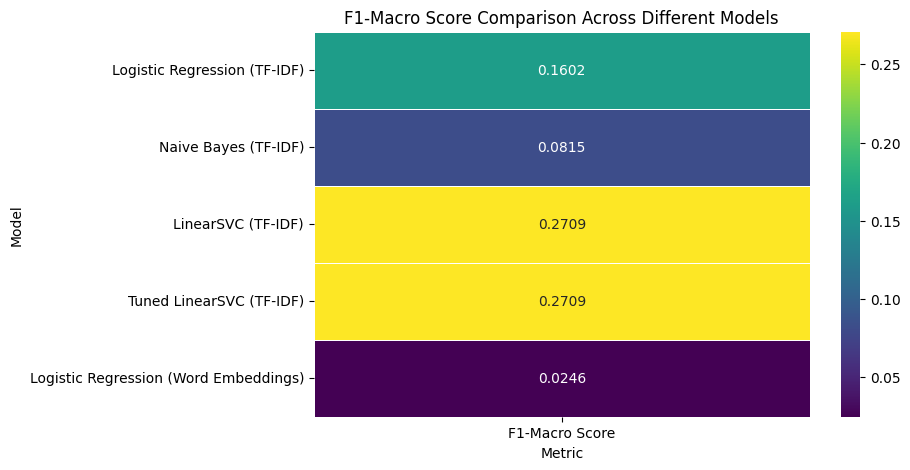

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gather F1-macro scores from all models
model_f1_scores = {
    'Logistic Regression (TF-IDF)': f1_macro,
    'Naive Bayes (TF-IDF)': f1_macro_nb,
    'LinearSVC (TF-IDF)': f1_macro_svm,
    'Tuned LinearSVC (TF-IDF)': f1_macro_best_lsvc,
    'Logistic Regression (Word Embeddings)': f1_macro_emb
}

# Convert to DataFrame for easier plotting
f1_scores_comparison_df = pd.DataFrame.from_dict(model_f1_scores, orient='index', columns=['F1-Macro Score'])

# Display the scores
print("F1-Macro Scores Comparison:")
display(f1_scores_comparison_df)

# Plot the heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(f1_scores_comparison_df, annot=True, cmap='viridis', fmt=".4f", linewidths=.5)
plt.title('F1-Macro Score Comparison Across Different Models')
plt.xlabel('Metric')
plt.ylabel('Model')
plt.show()

## 7. Prediction on Test Data and Submission File Generation
Let's make predictions on the test set and prepare a submission file.

In [9]:
print('\nF1-score for each genre (on validation set):')
f1_scores_per_genre = {}
for i, genre_name in enumerate(mlb.classes_):
    # Extract true and predicted labels for the current genre
    true_labels_genre = y_val[:, i]
    pred_labels_genre = y_pred[:, i]

    # Calculate F1-score for the current genre
    # Handle cases where a genre might not have any positive samples to avoid errors
    if np.sum(true_labels_genre) > 0:
        f1 = f1_score(true_labels_genre, pred_labels_genre, average='binary', zero_division=0)
        f1_scores_per_genre[genre_name] = f1
        print(f"  {genre_name}: {f1:.4f}")
    else:
        f1_scores_per_genre[genre_name] = np.nan # No true positive samples, F1 not applicable
        print(f"  {genre_name}: N/A (no true positive samples in validation set)")



F1-score for each genre (on validation set):
  action: 0.0860
  adult: 0.1488
  adventure: 0.0676
  animation: 0.0000
  biography: 0.0000
  comedy: 0.4060
  crime: 0.0185
  documentary: 0.7413
  drama: 0.5470
  family: 0.0392
  fantasy: 0.0000
  game-show: 0.2609
  history: 0.0000
  horror: 0.4254
  music: 0.3505
  musical: 0.0000
  mystery: 0.0000
  news: 0.0000
  reality-tv: 0.0600
  romance: 0.0000
  sci-fi: 0.0779
  short: 0.1894
  sport: 0.1373
  talk-show: 0.0476
  thriller: 0.0498
  war: 0.0000
  western: 0.6733


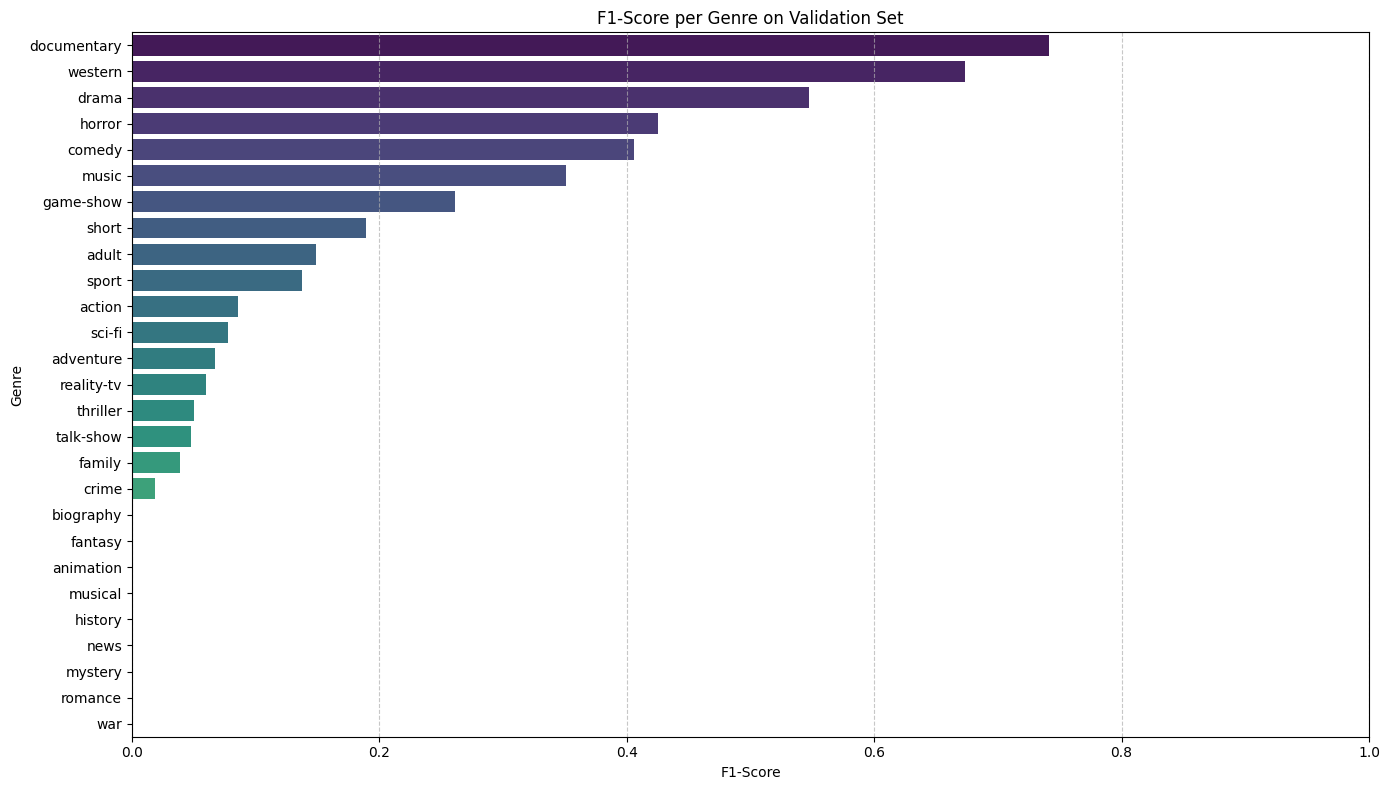

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the F1 scores dictionary to a DataFrame for plotting
f1_scores_df = pd.DataFrame(list(f1_scores_per_genre.items()), columns=['Genre', 'F1-Score'])

# Filter out N/A scores if any, or consider them as 0 for visualization purposes
f1_scores_df = f1_scores_df.dropna()

# Sort by F1-Score for better readability in the plot
f1_scores_df = f1_scores_df.sort_values(by='F1-Score', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='F1-Score', y='Genre', data=f1_scores_df, palette='viridis', hue='Genre', legend=False)
plt.title('F1-Score per Genre on Validation Set')
plt.xlabel('F1-Score')
plt.ylabel('Genre')
plt.xlim(0, 1) # F1-score ranges from 0 to 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


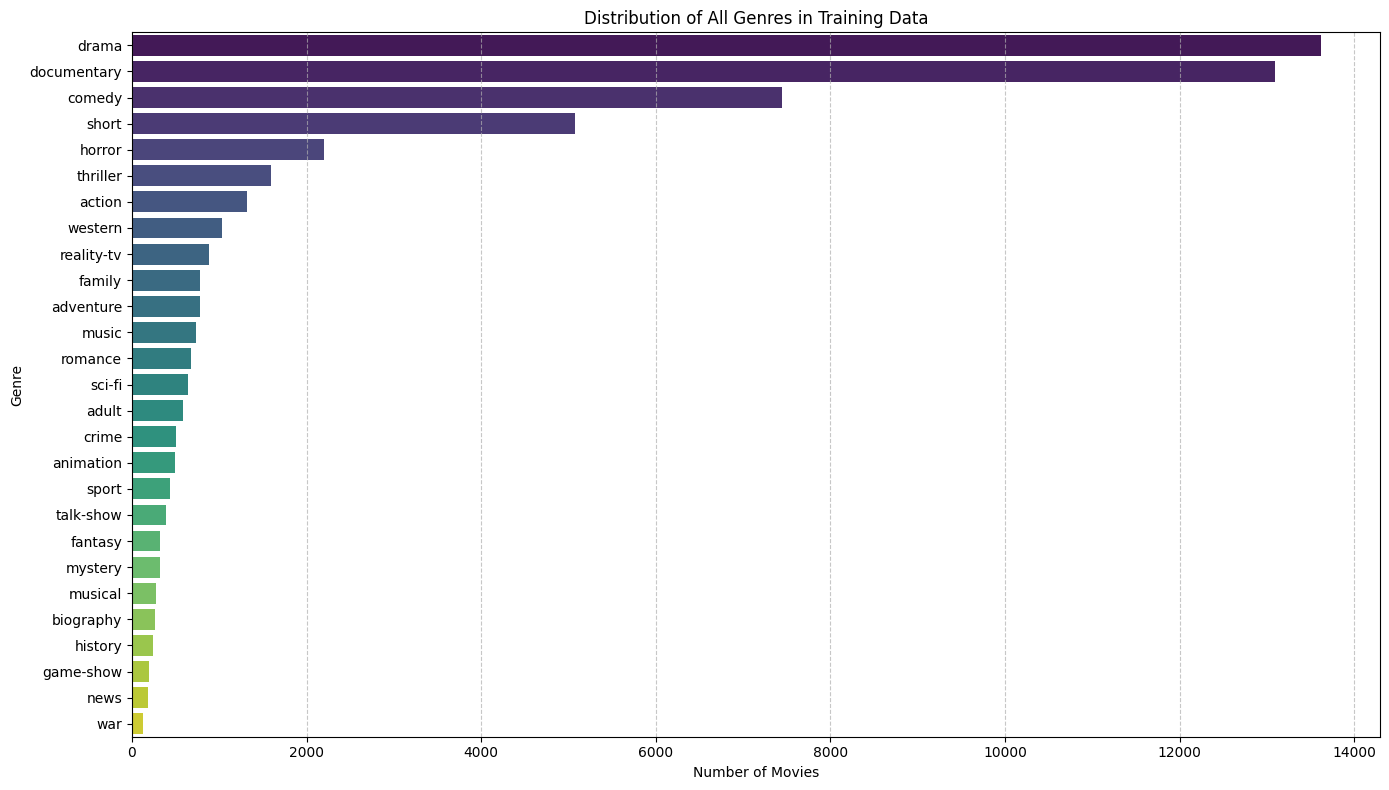

In [13]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Count', y='Genre', data=genre_counts_df, palette='viridis', hue='Genre', legend=False)
plt.title('Distribution of All Genres in Training Data')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [7]:
# Predict genres on the test set
y_test_pred_mlb = classifier.predict(X_test_tfidf)

# Convert predictions back to genre names
y_test_pred_genres = mlb.inverse_transform(y_test_pred_mlb)

# Create submission DataFrame
submission_df = pd.DataFrame({
    'ID': test_df['ID'],
    'TITLE': test_df['TITLE'],
    'DESCRIPTION': test_df['DESCRIPTION'],
    'GENRE': ['|'.join(genres) for genres in y_test_pred_genres] # Join genres with '|' for submission format
})

# Drop the 'DESCRIPTION' column if it's not required in the final output
# Based on the description.txt, the test data solution format only has ID, TITLE, DESCRIPTION, GENRE
# However, typically only ID and predicted GENRE are submitted. Let's keep the format consistent with the train_data for now, assuming it will be evaluated based on GENRE.
# If a specific submission format is required (e.g., only ID and GENRE), this can be adjusted.

# Save the submission file (assuming format like train_data: ID ::: TITLE ::: GENRE ::: DESCRIPTION)
# However, judging from test_data_solution.txt, the format might be different for evaluation.
# Let's create a file with ID and predicted genres, similar to how the data was read.

submission_lines = []
for index, row in submission_df.iterrows():
    # Use TITLE and DESCRIPTION from the original test_df to preserve original casing/punctuation if needed
    # But for a submission, usually only ID and predicted genre are needed.
    # Let's create a simple submission with ID and predicted genres.
    submission_lines.append(f"{row['ID']} ::: {test_df.loc[index, 'TITLE']} ::: {row['GENRE']} ::: {test_df.loc[index, 'DESCRIPTION']}")

output_filename = 'submission.txt'
with open(output_filename, 'w') as f:
    for line in submission_lines:
        f.write(line + '\n')

print(f"Submission file '{output_filename}' created successfully.")
print("First 5 lines of the submission file:")
for i in range(min(5, len(submission_lines))):
    print(submission_lines[i])

Submission file 'submission.txt' created successfully.
First 5 lines of the submission file:
1 ::: Edgar's Lunch (1998) :::  ::: L.R. Brane loves his life - his car, his apartment, his job, but especially his girlfriend, Vespa. One day while showering, Vespa runs out of shampoo. L.R. runs across the street to a convenience store to buy some more, a quick trip of no more than a few minutes. When he returns, Vespa is gone and every trace of her existence has been wiped out. L.R.'s life becomes a tortured existence as one strange event after another occurs to confirm in his mind that a conspiracy is working against his finding Vespa.
2 ::: La guerra de papá (1977) ::: drama ::: Spain, March 1964: Quico is a very naughty child of three belonging to a wealthy middle-class family. Since Cristina's birth, he feels he has lost the privileged position of "prince" of the house for his eight months old sister. So, with his brother Juan, who is eight years old and is quite disobedient, spend their

## 8. Save Predictions to CSV
Let's save the `submission_df` containing the test set predictions to a CSV file.

In [8]:
submission_csv_filename = 'submission.csv'
submission_df.to_csv(submission_csv_filename, index=False)

print(f"Test set predictions saved to '{submission_csv_filename}' successfully.")
print("First 5 rows of the CSV file:")
with open(submission_csv_filename, 'r') as f:
    for i, line in enumerate(f):
        if i >= 6: # Print header + 5 rows
            break
        print(line.strip())

Test set predictions saved to 'submission.csv' successfully.
First 5 rows of the CSV file:
ID,TITLE,DESCRIPTION,GENRE
1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apartment, his job, but especially his girlfriend, Vespa. One day while showering, Vespa runs out of shampoo. L.R. runs across the street to a convenience store to buy some more, a quick trip of no more than a few minutes. When he returns, Vespa is gone and every trace of her existence has been wiped out. L.R.'s life becomes a tortured existence as one strange event after another occurs to confirm in his mind that a conspiracy is working against his finding Vespa.",
2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty child of three belonging to a wealthy middle-class family. Since Cristina's birth, he feels he has lost the privileged position of ""prince"" of the house for his eight months old sister. So, with his brother Juan, who is eight years old and is quite disobedient, spend their